In [1]:
import re
import os
import glob
import hashlib
from collections import Counter
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm


In [2]:
directory = Path("data")
train = directory / "train"
test = directory / "test"
val = directory / "val"
for path in [train, test, val]:
    if not path.exists():
        print(f"{path} does not exist")
    else:
        print(f"{path} exists")

data\train exists
data\test exists
data\val exists


In [3]:
for path in ["train", "test", "val"]:
    full_path  = directory / path
    print(f"\nContents of {full_path}:")
    for item in full_path.iterdir():
        print(" ",item.name,"->","DIR" if item.is_dir() else "FILE")


Contents of data\train:
  awake -> DIR
  sleepy -> DIR

Contents of data\test:
  awake -> DIR
  sleepy -> DIR

Contents of data\val:
  awake -> DIR
  sleepy -> DIR


In [4]:
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp"]
def get_image_files(directory):
    return [p for p in directory.rglob("*") if p.is_file() and p.suffix.lower() in image_extensions]

dic = {}
for path in ["train", "test", "val"]:
    full_path  = directory / path
    image_files = get_image_files(full_path)
    dic[path] = image_files
for key, value in dic.items():
    print(f"Number of images in {key}: {len(value)}")

Number of images in train: 50937
Number of images in test: 16970
Number of images in val: 16980


In [5]:
extension_counter = Counter(
    file.suffix.lower()
    for files in dic.values()
    for file in files
)
for key, value in extension_counter.items():
    print(f"Extension: {key}, Count: {value}")

Extension: .png, Count: 84887


In [6]:
def parse_filename(path):
    name = path.stem
    parts = name.split("_")
    if len(parts)!=8:
        return None
    return{
        "filename":path.name,
        "path": str(path),
        "subject_id": parts[0],
        "image_id": parts[1],
        "gender": int(parts[2]),
        "glasses": int(parts[3]),
        "eye_state": int(parts[4]),
        "reflection": int(parts[5]),
        "lighting": int(parts[6]),
        "sensor": parts[7],
    }

records = []
for key,value in dic.items():
    for file in tqdm(value, desc=f"Parsing {key}"):
        metadata = parse_filename(file)
        if metadata is not None:
            metadata["File"] = key
            records.append(metadata)
df = pd.DataFrame(records)
df.head()  

Parsing val: 100%|██████████| 16980/16980 [00:00<00:00, 271441.84it/s]


,filename,path,subject_id,image_id,gender,glasses,eye_state,reflection,lighting,sensor,File
0,s0001_01842_0_0_1_0_0_01.png,data\train\awake\s0001_01842_0_0_1_0_0_01.png,s0001,01842,0,0,1,0,0,01,train
1,s0001_01843_0_0_1_0_0_01.png,data\train\awake\s0001_01843_0_0_1_0_0_01.png,s0001,01843,0,0,1,0,0,01,train
2,s0001_01845_0_0_1_0_0_01.png,data\train\awake\s0001_01845_0_0_1_0_0_01.png,s0001,01845,0,0,1,0,0,01,train
3,s0001_01848_0_0_1_0_0_01.png,data\train\awake\s0001_01848_0_0_1_0_0_01.png,s0001,01848,0,0,1,0,0,01,train
4,s0001_01852_0_0_1_0_0_01.png,data\train\awake\s0001_01852_0_0_1_0_0_01.png,s0001,01852,0,0,1,0,0,01,train


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84887 entries, 0 to 84886
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   filename    84887 non-null  object
 1   path        84887 non-null  object
 2   subject_id  84887 non-null  object
 3   image_id    84887 non-null  object
 4   gender      84887 non-null  int64 
 5   glasses     84887 non-null  int64 
 6   eye_state   84887 non-null  int64 
 7   reflection  84887 non-null  int64 
 8   lighting    84887 non-null  int64 
 9   sensor      84887 non-null  object
 10  File        84887 non-null  object
dtypes: int64(5), object(6)
memory usage: 7.1+ MB


In [8]:
df["eye_state_label"] = df["eye_state"].map({0: "Open", 1: "Closed"})

In [9]:
df.head()

,filename,path,subject_id,image_id,gender,glasses,eye_state,reflection,lighting,sensor,File,eye_state_label
0,s0001_01842_0_0_1_0_0_01.png,data\train\awake\s0001_01842_0_0_1_0_0_01.png,s0001,01842,0,0,1,0,0,01,train,Closed
1,s0001_01843_0_0_1_0_0_01.png,data\train\awake\s0001_01843_0_0_1_0_0_01.png,s0001,01843,0,0,1,0,0,01,train,Closed
2,s0001_01845_0_0_1_0_0_01.png,data\train\awake\s0001_01845_0_0_1_0_0_01.png,s0001,01845,0,0,1,0,0,01,train,Closed
3,s0001_01848_0_0_1_0_0_01.png,data\train\awake\s0001_01848_0_0_1_0_0_01.png,s0001,01848,0,0,1,0,0,01,train,Closed
4,s0001_01852_0_0_1_0_0_01.png,data\train\awake\s0001_01852_0_0_1_0_0_01.png,s0001,01852,0,0,1,0,0,01,train,Closed


C:\Users\HARSH VARDHAN SHUKLA\AppData\Local\Temp\ipykernel_33636\1992995589.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="eye_state_label", palette="Set2")


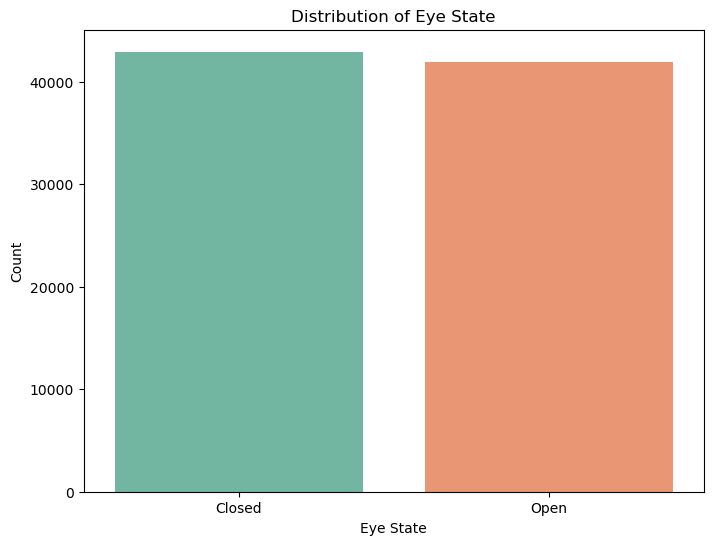

In [10]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="eye_state_label", palette="Set2")
plt.title("Distribution of Eye State")
plt.xlabel("Eye State")
plt.ylabel("Count")
plt.show()

In [11]:
crosstab = pd.crosstab(df["File"],df["eye_state_label"],margins=True,normalize="index").style.background_gradient(cmap="YlGnBu").format("{:.2%}")
crosstab

eye_state_label,Closed,Open
File,,
test,50.56%,49.44%
train,50.59%,49.41%
val,50.59%,49.41%
All,50.59%,49.41%


Number of unique subjects: 37
subject_id
s0037    10257
s0014     8884
s0012     8728
s0036     6193
s0019     6175
s0032     6162
s0018     4410
s0013     3605
s0001     3231
s0016     1889
s0031     1738
s0011     1648
s0017     1648
s0025     1502
s0029     1393
s0030     1384
s0026     1246
s0015     1132
s0002     1114
s0004     1069
s0006     1012
s0021      987
s0008      832
s0024      752
s0034      739
s0028      736
s0005      736
s0020      704
s0033      681
s0003      679
s0027      665
s0035      642
s0007      624
s0023      522
s0010      399
s0009      387
s0022      382
Name: count, dtype: int64


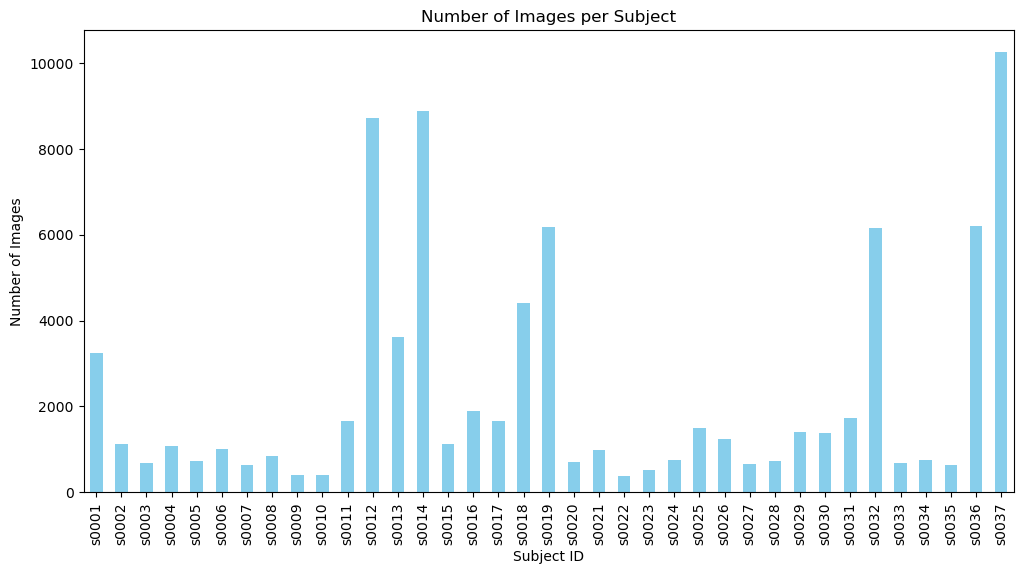

In [12]:
subject_counts = df["subject_id"].value_counts()
print(f"Number of unique subjects: {len(subject_counts)}")
print(subject_counts)

plt.figure(figsize=(12,6))
subject_counts.sort_index().plot(kind="bar", color="skyblue")
plt.title("Number of Images per Subject")
plt.xlabel("Subject ID")
plt.ylabel("Number of Images")
plt.show()

In [13]:
train_subjects = set(df[df["File"]=="train"]["subject_id"])
test_subjects = set(df[df["File"]=="test"]["subject_id"])
val_subjects = set(df[df["File"]=="val"]["subject_id"])
print(f"Train subjects count: {len(train_subjects)}")
print(f"Test subjects count: {len(test_subjects)}")
print(f"Validation subjects count: {len(val_subjects)}")    

print(f"Train and validation subjects overlap: {train_subjects.intersection(val_subjects)}")
print(f"Train and test subjects overlap: {train_subjects.intersection(test_subjects)}") 
print(f"Validation and test subjects overlap: {val_subjects.intersection(test_subjects)}")

Train subjects count: 37
Test subjects count: 37
Validation subjects count: 37
Train and validation subjects overlap: {'s0028', 's0012', 's0030', 's0010', 's0014', 's0017', 's0026', 's0001', 's0034', 's0037', 's0002', 's0031', 's0019', 's0005', 's0007', 's0036', 's0020', 's0022', 's0009', 's0035', 's0024', 's0025', 's0011', 's0003', 's0023', 's0004', 's0033', 's0013', 's0016', 's0021', 's0008', 's0006', 's0018', 's0027', 's0032', 's0029', 's0015'}
Train and test subjects overlap: {'s0028', 's0012', 's0030', 's0010', 's0014', 's0017', 's0026', 's0001', 's0034', 's0037', 's0002', 's0031', 's0019', 's0005', 's0007', 's0036', 's0020', 's0022', 's0009', 's0035', 's0024', 's0025', 's0011', 's0003', 's0023', 's0004', 's0033', 's0013', 's0016', 's0021', 's0008', 's0006', 's0018', 's0027', 's0032', 's0029', 's0015'}
Validation and test subjects overlap: {'s0028', 's0012', 's0030', 's0010', 's0014', 's0017', 's0026', 's0001', 's0034', 's0037', 's0002', 's0031', 's0019', 's0005', 's0007', 's0036'

C:\Users\HARSH VARDHAN SHUKLA\AppData\Local\Temp\ipykernel_33636\265521846.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="glasses_lable", palette="Set2")


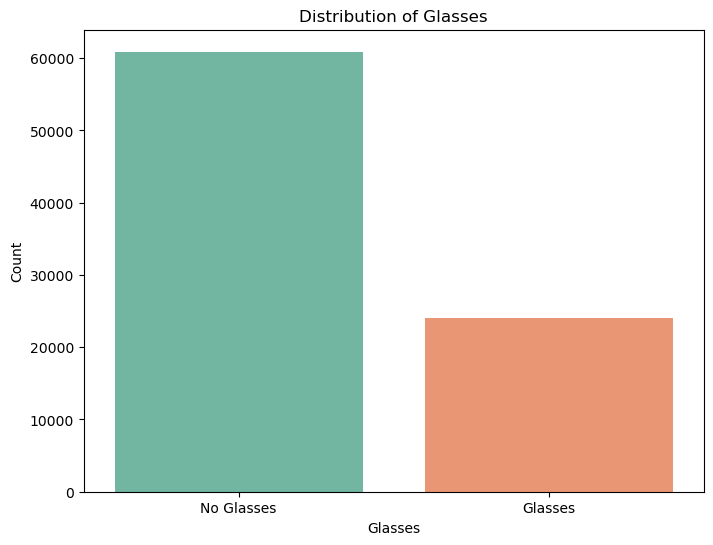

In [14]:
df["glasses_lable"] = df["glasses"].map({0: "No Glasses", 1: "Glasses"})    

plt.figure(figsize=(8,6))
sns.countplot(data=df, x="glasses_lable", palette="Set2")
plt.title("Distribution of Glasses")
plt.xlabel("Glasses")
plt.ylabel("Count")
plt.show()

C:\Users\HARSH VARDHAN SHUKLA\AppData\Local\Temp\ipykernel_33636\2590680727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="lighting_label", palette="Set2")


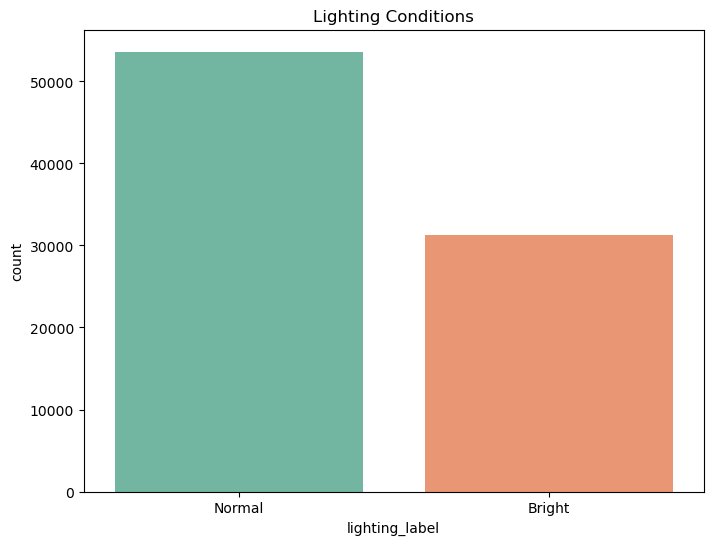

eye_state_label,Closed,Open
lighting_label,,
Bright,61.516566,38.483434
Normal,44.211940,55.788060


In [15]:
df["lighting_label"] = df["lighting"].map({0: "Normal", 1: "Bright"})
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="lighting_label", palette="Set2")
plt.title("Lighting Conditions")
plt.show()

pd.crosstab(
    df["lighting_label"], df["eye_state_label"],normalize="index"
)*100

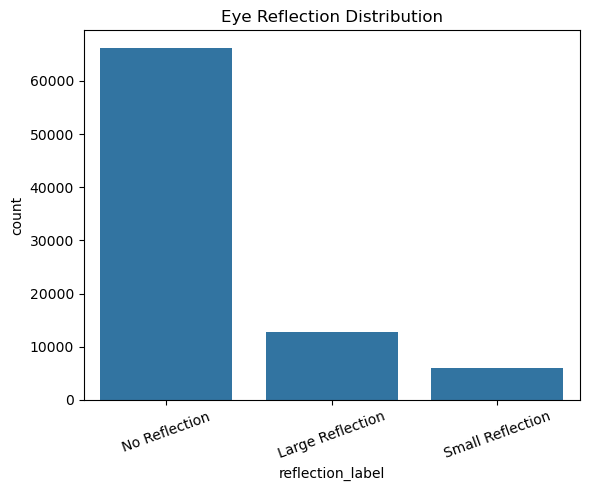

In [16]:
reflection_map = {
    0: "No Reflection",
    1: "Small Reflection",
    2: "Large Reflection"
}

df["reflection_label"] = df["reflection"].map(reflection_map)
sns.countplot(
    data=df,
    x="reflection_label"
)

plt.title("Eye Reflection Distribution")
plt.xticks(rotation=20)

plt.show()

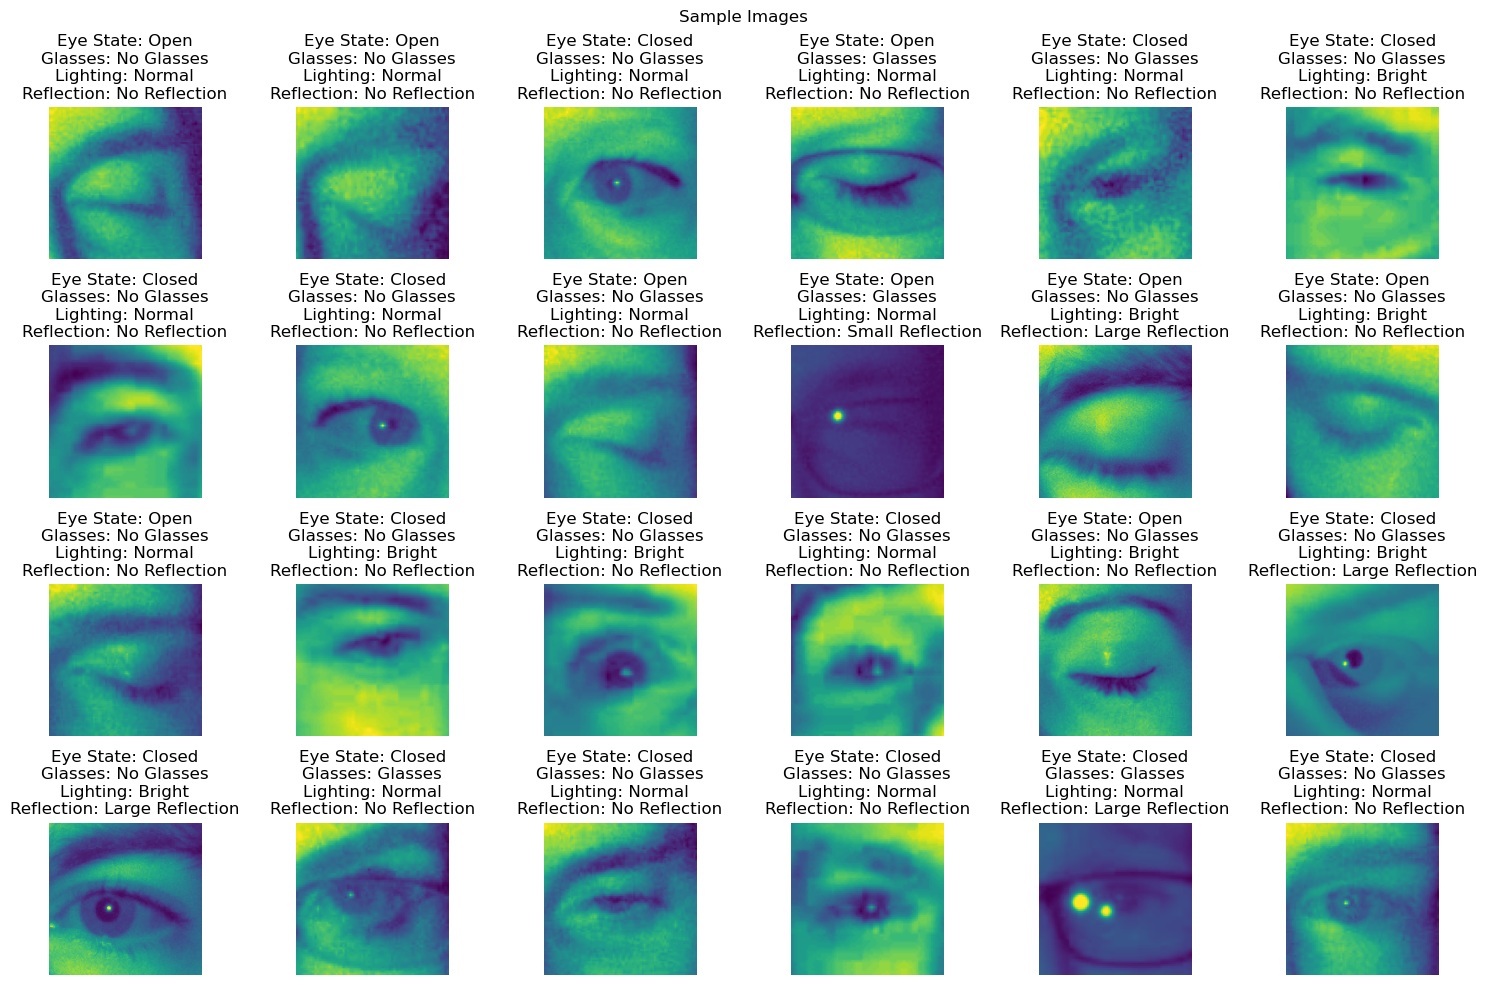

In [17]:
def show_sample(dataframe,n=24):
    sample = dataframe.sample(min(n, len(dataframe)))
    fig,axes = plt.subplots(4,6, figsize=(15,10))
    axes = axes.ravel()
    for ax,(_,row) in zip(axes, sample.iterrows()):
        img = Image.open(row["path"])
        ax.imshow(img)
        ax.set_title(f"Eye State: {row['eye_state_label']}\nGlasses: {row['glasses_lable']}\nLighting: {row['lighting_label']}\nReflection: {row['reflection_label']}")
        ax.axis("off")
    fig.suptitle("Sample Images")
    plt.tight_layout()
    plt.show()

show_sample(df, 24)

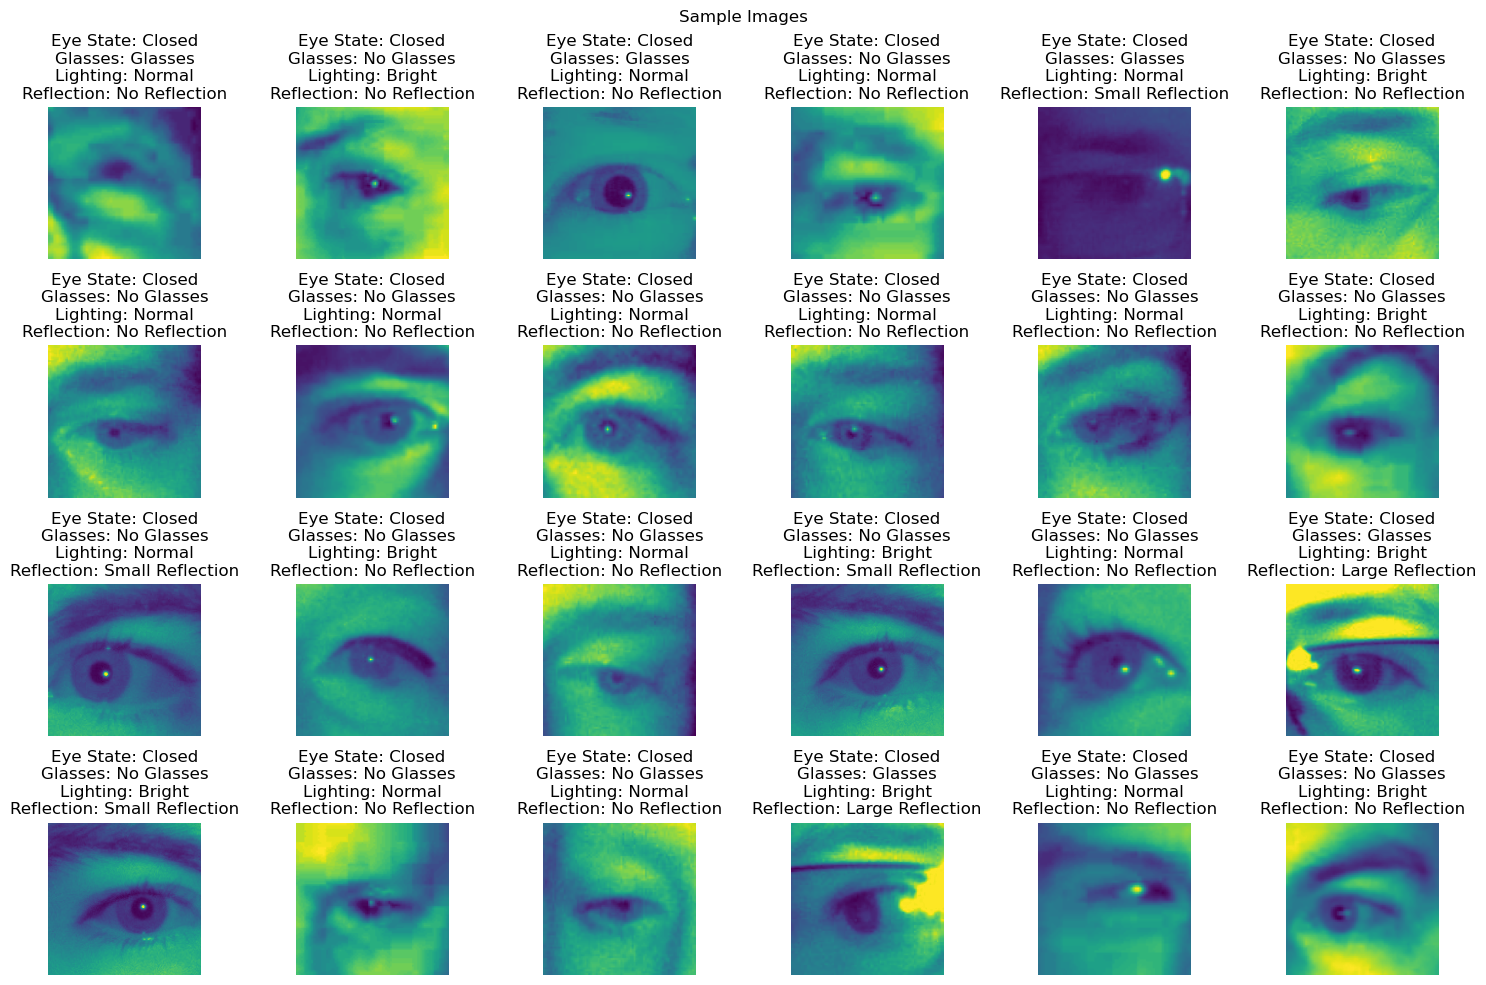

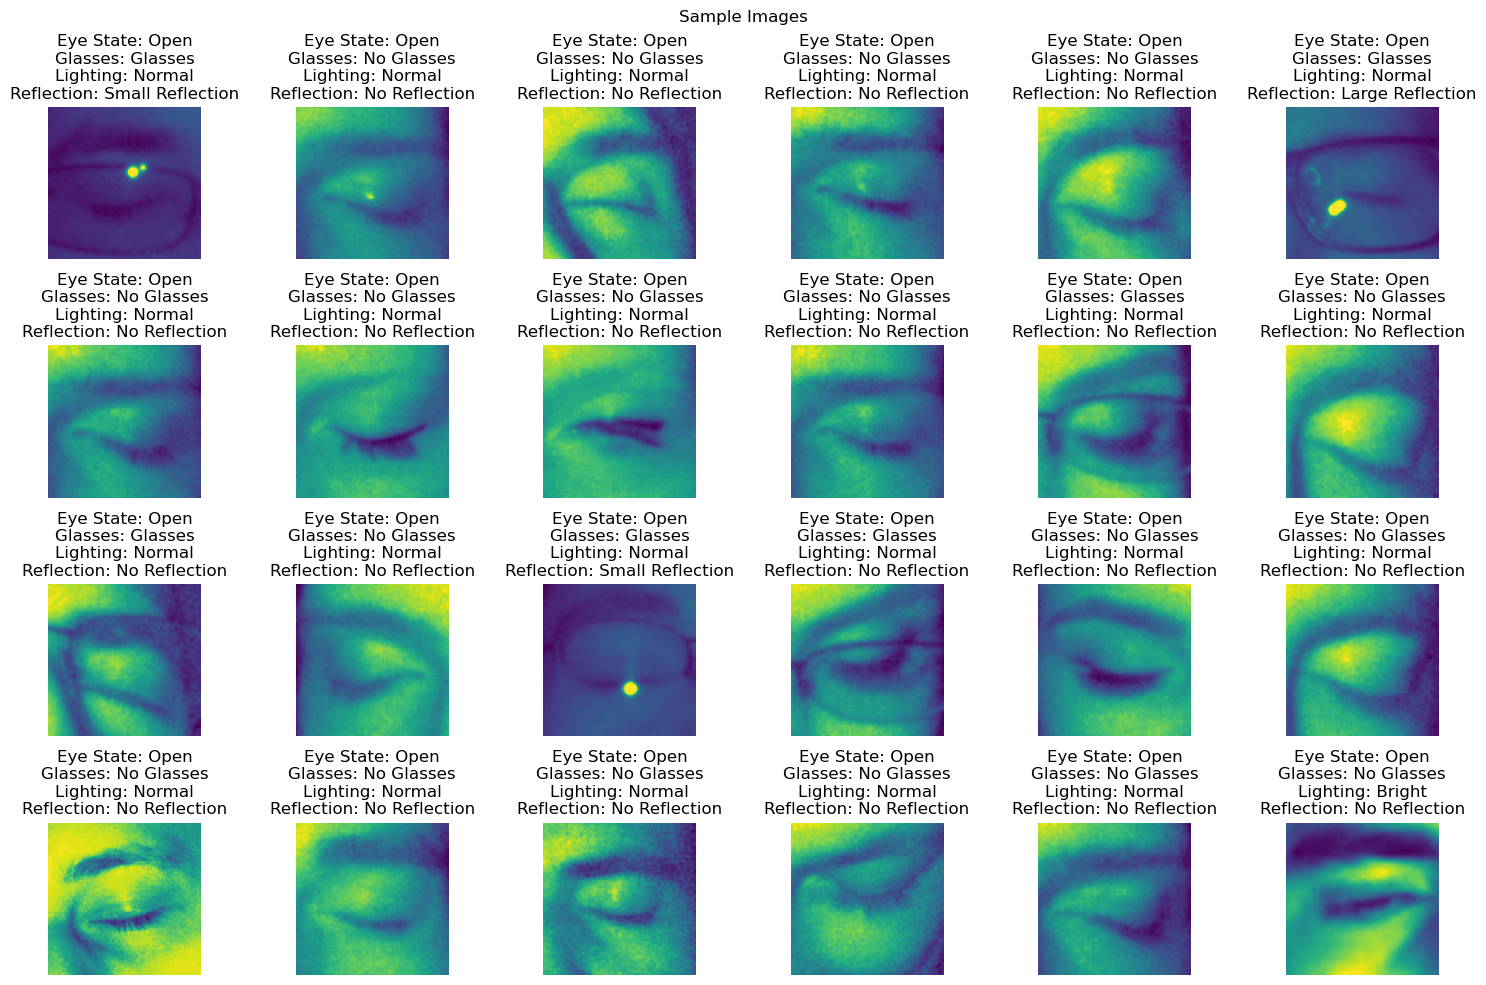

In [18]:
closed = df[df["eye_state"]==1]
opened = df[df["eye_state"]==0]

show_sample(closed, 24)
show_sample(opened, 24)

In [19]:
def img_info(path):
    try:
        with Image.open(path) as img:
            return {
                "height": img.height,
                "width": img.width,
                "mode": img.mode
            }
    except Exception as e:
        return{
            "height": None,
            "width": None, 
            "mode": None
        }
image_info_list = []
for path in tqdm(df["path"], desc="Getting image info"):
    info = img_info(path)
    image_info_list.append(info)

df = pd.concat([df, pd.DataFrame(image_info_list)], axis=1)


Getting image info: 100%|██████████| 84887/84887 [01:26<00:00, 982.53it/s] 


In [20]:

df["mode"].value_counts()

mode
L    84887
Name: count, dtype: int64

In [21]:
sample = df.sample(1000, random_state=42)
mean = []
stds = []
mins = []
maxs = []
for path in tqdm(sample["path"], desc="Calculating image statistics"):
    grey = Image.open(path).convert("L")
    arr = np.array(grey)
    mean.append(np.mean(arr))
    stds.append(np.std(arr))
    mins.append(np.min(arr))
    maxs.append(np.max(arr))

pixel_stats = pd.DataFrame({
    "mean": mean,
    "std": stds,    
    "mins": mins,
    "maxs": maxs
})
pixel_stats.describe()

Calculating image statistics: 100%|██████████| 1000/1000 [00:01<00:00, 901.97it/s]


,mean,std,mins,maxs
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,89.152695,18.909197,42.289000,153.053000
std,27.206905,10.021799,16.763547,58.670951
min,42.483525,4.719315,0.000000,72.000000
25%,71.474332,12.872727,31.000000,109.000000
50%,84.187011,15.333376,42.000000,129.000000
75%,97.891560,22.171144,54.000000,194.250000
max,208.955762,54.406408,108.000000,255.000000


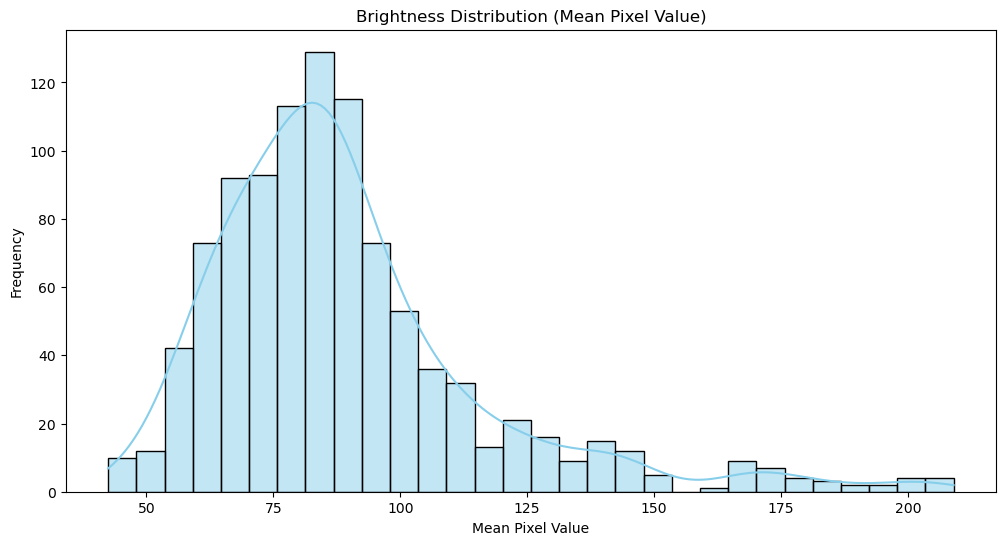

In [22]:
plt.figure(figsize=(12,6))
sns.histplot(
    pixel_stats["mean"], bins=30, kde=True, color="skyblue"
)
plt.title("Brightness Distribution (Mean Pixel Value)")
plt.xlabel("Mean Pixel Value")
plt.ylabel("Frequency") 
plt.show()

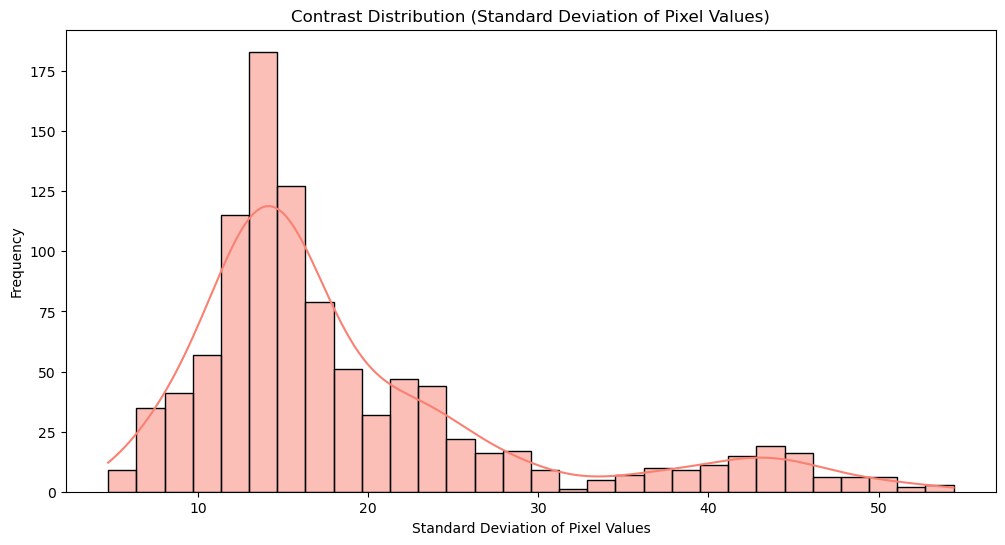

In [23]:
plt.figure(figsize=(12,6))
sns.histplot(
    pixel_stats["std"], bins=30, kde=True, color="salmon"
)
plt.title("Contrast Distribution (Standard Deviation of Pixel Values)")
plt.xlabel("Standard Deviation of Pixel Values")
plt.ylabel("Frequency")
plt.show()

In [24]:
def md5_hash(path):
    hash_md5 = hashlib.md5()
    
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hash_md5.update(chunk)
    
    return hash_md5.hexdigest()

hashes = []

for path in tqdm(df["path"], desc="Hashing images"):
    hashes.append(md5_hash(path))

df["md5"] = hashes

duplicate_groups = df[df["md5"].duplicated(keep=False)].sort_values("md5")

print("Images involved in exact duplicates:",
      len(duplicate_groups))

Hashing images: 100%|██████████| 84887/84887 [00:20<00:00, 4117.23it/s]

Images involved in exact duplicates: 76


In [27]:
duplicate_split = (
    duplicate_groups
    .groupby("md5")["File"]
    .nunique()
)

cross_split_duplicates = duplicate_split[
    duplicate_split > 1
]

print(
    "Duplicate groups crossing dataset splits:",
    len(cross_split_duplicates)
)

Duplicate groups crossing dataset splits: 22


In [28]:
subject_class = pd.crosstab(
    df["subject_id"], df["eye_state_label"], margins=True, normalize="index"
)
subject_class.head()

eye_state_label,Closed,Open
subject_id,,
s0001,0.430207,0.569793
s0002,0.096050,0.903950
s0003,0.176730,0.823270
s0004,0.000000,1.000000
s0005,0.038043,0.961957


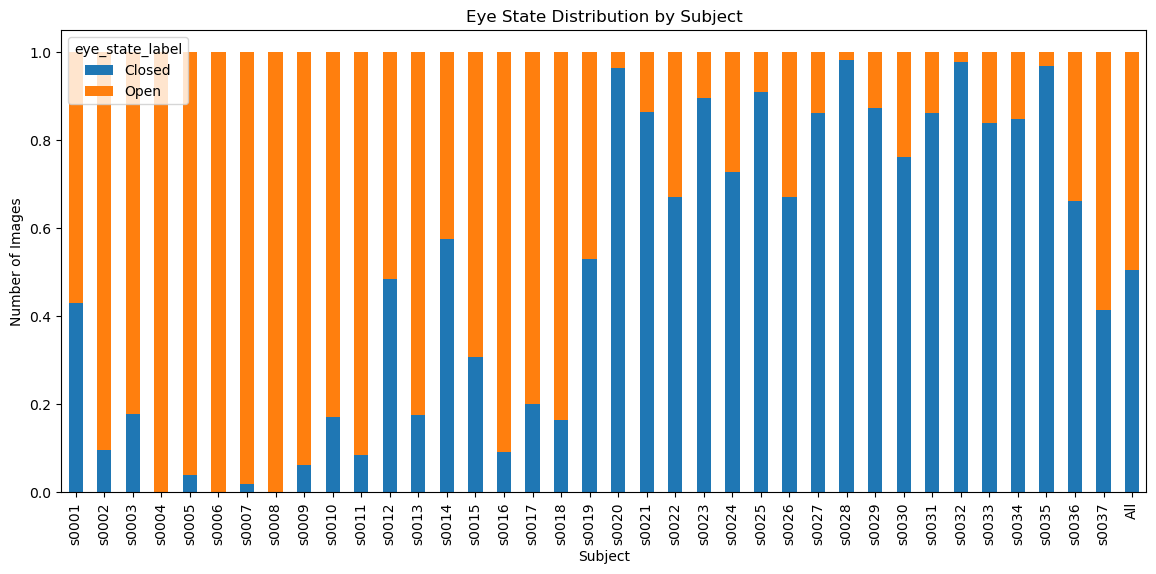

In [29]:
subject_class.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Eye State Distribution by Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Images")

plt.show()

In [32]:
glasses_eye = pd.crosstab(
    df["glasses_lable"],
    df["eye_state_label"],
    normalize="index"
) * 100

glasses_eye

eye_state_label,Closed,Open
glasses_lable,,
Glasses,40.552477,59.447523
No Glasses,54.541274,45.458726


In [33]:
lighting_eye = pd.crosstab(
    df["lighting_label"],
    df["eye_state_label"],
    normalize="index"
) * 100

lighting_eye

eye_state_label,Closed,Open
lighting_label,,
Bright,61.516566,38.483434
Normal,44.211940,55.788060


In [34]:
lighting_eye = pd.crosstab(
    df["lighting_label"],
    df["eye_state_label"],
    normalize="index"
) * 100

lighting_eye

eye_state_label,Closed,Open
lighting_label,,
Bright,61.516566,38.483434
Normal,44.211940,55.788060


In [35]:
summary = {
    "total_images": len(df),
    "train_images": len(df[df["File"] == "train"]),
    "validation_images": len(df[df["File"] == "val"]),
    "test_images": len(df[df["File"] == "test"]),
    "unique_subjects": df["subject_id"].nunique(),
    "closed_images": (df["eye_state"] == 0).sum(),
    "open_images": (df["eye_state"] == 1).sum(),
    "unique_dimensions": df[["width", "height"]].drop_duplicates().shape[0],
    "unique_modes": df["mode"].nunique(),
}

pd.Series(summary)

total_images         84887
train_images         50937
validation_images    16980
test_images          16970
unique_subjects         37
closed_images        41946
open_images          42941
unique_dimensions      236
unique_modes             1
dtype: int64